## Q2: Interpolation error

There are a large number of different interpolation schemes available through scipy.  Let's test them out.

Create a python function, $f(x)$, that is your true function (make it complicated!).  Now create $N$ samples of it (either regularly spaced or irregularly spaced).

Try some of the different interpolation routines.  `interpolate.interp1d` takes a `kind` argument that lets you choose the order of the interpolation.  Measure the error in the method, by comparing the interpolated result with the actual function value.  

Then do the same cubic splines (look at `CubicSpline`)

Plot the resulting interpolant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

In [2]:
def f(x):
    return np.sin(x)**2 + 0.1 * np.cos(5*x) * np.abs(x)**(2/3)

N = 30
x_sample = np.linspace(0, 20, N)
y_sample = f(x_sample)

x_true = np.linspace(0, 20, 200)
y_true = f(x_true)

f_linear = interpolate.interp1d(x_sample, y_sample, kind="linear")
f_quad = interpolate.interp1d(x_sample, y_sample, kind="quadratic")
f_cubic = interpolate.interp1d(x_sample, y_sample, kind="cubic")
f_spline = interpolate.CubicSpline(x_sample, y_sample)

y_interp_linear = f_linear(x_true)
y_interp_quad = f_quad(x_true)
y_interp_cubic = f_cubic(x_true)
y_interp_spline = f_spline(x_true)

error_linear = np.abs(y_true - y_interp_linear)
error_quad = np.abs(y_true - y_interp_quad)
error_cubic = np.abs(y_true - y_interp_cubic)

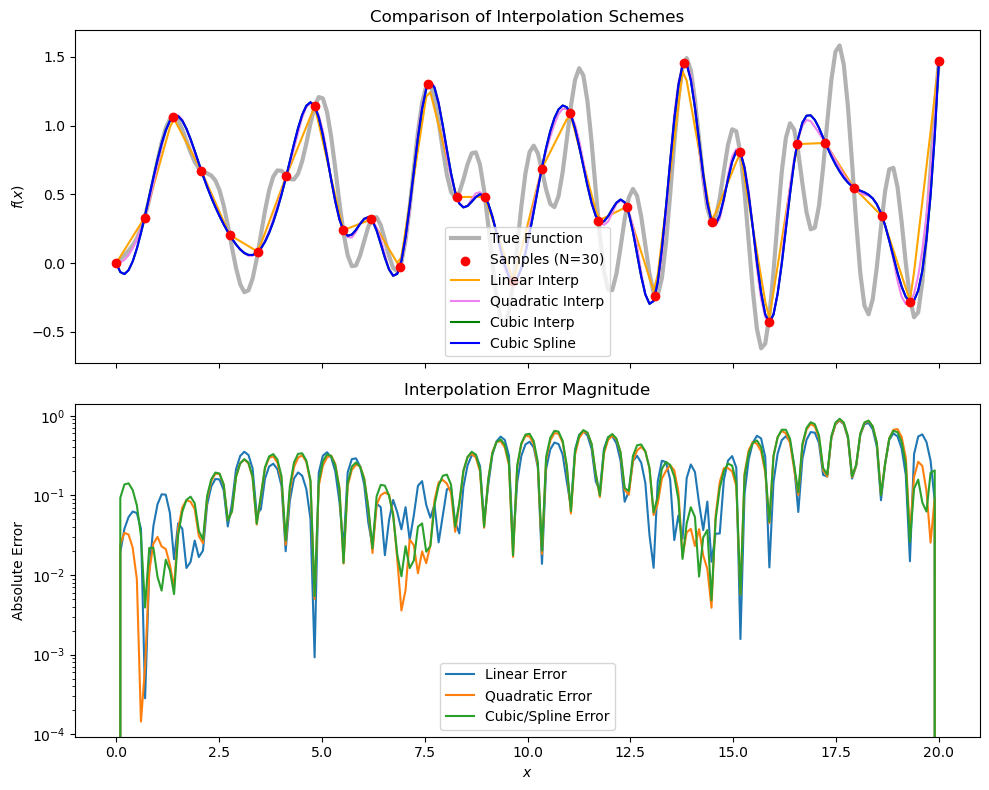

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(x_true, y_true, label="True Function", color="black", alpha=0.3, lw=3)
ax1.scatter(x_sample, y_sample, color="red", label=f"Samples (N={N})", zorder=5)
ax1.plot(x_true, y_interp_linear, label="Linear Interp", color="orange")
ax1.plot(x_true, y_interp_quad, label="Quadratic Interp", color="violet")
ax1.plot(x_true, y_interp_cubic, label="Cubic Interp", color="green")
ax1.plot(x_true, y_interp_spline, label="Cubic Spline", color="blue")
ax1.set_ylabel(r"$f(x)$")
ax1.legend()
ax1.set_title("Comparison of Interpolation Schemes")

ax2.plot(x_true, error_linear, label="Linear Error")
ax2.plot(x_true, error_quad, label="Quadratic Error")
ax2.plot(x_true, error_cubic, label="Cubic/Spline Error")
ax2.set_yscale("log")
ax2.set_ylabel("Absolute Error")
ax2.set_xlabel(r"$x$")
ax2.legend()
ax2.set_title("Interpolation Error Magnitude")

plt.tight_layout()
plt.show()

## Q7: Noisy signal

A convolution is defined as:  

\begin{equation}  
  (f \star g)(t) \equiv \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau \tag{1}  
\end{equation}  

It is easy to compute this with FFTs, via the _convolution theorem_,  

\begin{equation}  
  \mathcal{F}\{f \star g\} = \mathcal{F}\{f\} \, \mathcal{F}\{g\} \tag{2}  
\end{equation}  

That is: the Fourier transform of the convolution of $f$ and $g$ is simply the product of the individual transforms of $f$ and $g$. This allows us to compute the convolution via multiplication in Fourier space and then take the inverse transform, $\mathcal{F}^{-1}\{\}$, to recover the convolution in real space:

\begin{equation}  
  f \star g = \mathcal{F}^{-1}\{ \mathcal{F}\{f\} \, \mathcal{F}\{g\}\} \tag{3}  
\end{equation}  

A common use of a convolution is to smooth noisy data, for example by convolving noisy data with a Gaussian. We'll do that here.

Here's some noisy data we'll work with

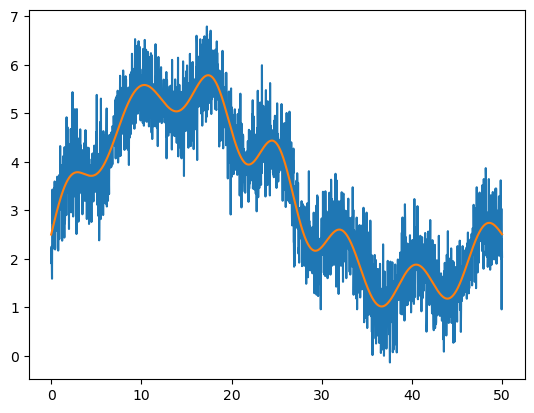

In [4]:
def fdata(x, L):
    A = L/10.0
    return 2*np.sin(2*np.pi*x/L) + x*(L-x)**2/L**3 * np.cos(x) + \
           5*x*(L-x)/L**2 + A/2 + 0.1*A*np.sin(13*np.pi*x/L)

N = 2048
L = 50.0
x = np.linspace(0, L, N, endpoint=False)
orig = fdata(x, L)
noisy = orig + 0.5*np.random.randn(N)

plt.plot(x, noisy)
plt.plot(x, orig)

SciPy provides a convolution function `scipy.signal.convolve()` that can do the convolution for us directly.  To smooth the data, we want to use a Gaussian, which can be produced by `scipy.signal.windows.gaussian()`.

Convolve the noisy data with a Gaussian and plot the result together with the original data `orig`.  You'll need to play with the width of the Gaussian to get a nice smoothing.  You also will need to normalize the Gaussian so that it sums to 1, otherwise, your convolved data will be shifted verfically from the original function.

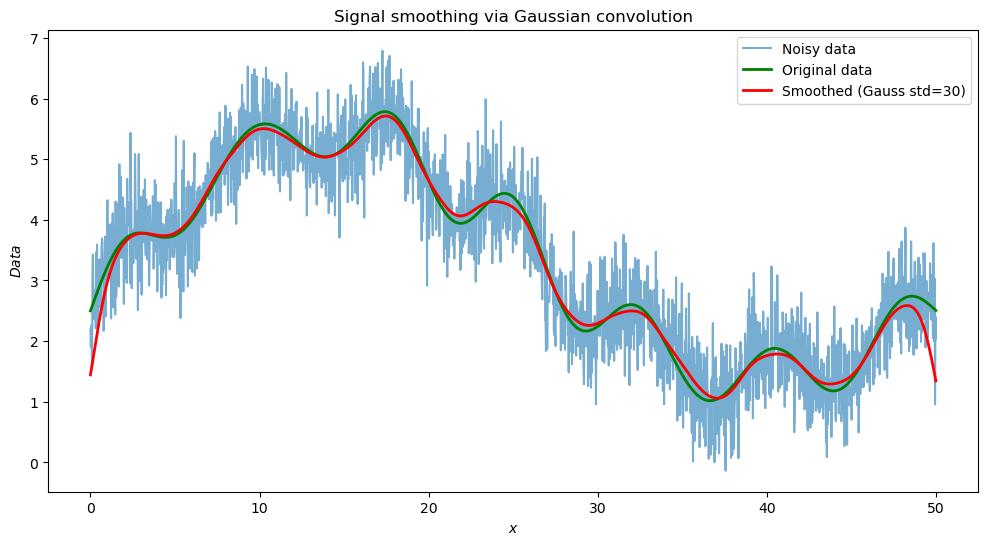

In [5]:
from scipy import signal

M = 200 
std_gauss = 30
gauss_kernel = signal.windows.gaussian(M, std=std_gauss)

gauss_kernel /= np.sum(gauss_kernel)

smoothed = signal.convolve(noisy, gauss_kernel, mode='same')

plt.figure(figsize=(12, 6))
plt.plot(x, noisy, label="Noisy data", alpha=0.6)
plt.plot(x, orig, label="Original data", color='green', lw=2)
plt.plot(x, smoothed, label=f"Smoothed (Gauss std={std_gauss})", color='red', lw=2)

plt.title(r"Signal smoothing via Gaussian convolution")
plt.xlabel(r"$x$")
plt.ylabel(r"$Data$")
plt.legend()
plt.show()